In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# Cell 1 — Check GPU and dataset
import os
import torch

print(f"✓ PyTorch  : {torch.__version__}")
print(f"✓ Device   : {'GPU' if torch.cuda.is_available() else 'CPU'}")
if torch.cuda.is_available():
    print(f"✓ GPU name : {torch.cuda.get_device_name(0)}")

# check dataset path
EYEDENTIFY = "/kaggle/input/datasets/vijuls/pupildiameterdatasets/eyedentify/eyedentify"
print(f"\nEyeDentify exists: {os.path.exists(EYEDENTIFY)}")

# check left eyes
LEFT = os.path.join(EYEDENTIFY, "left_eyes")
if os.path.exists(LEFT):
    subjects = sorted(os.listdir(LEFT))
    print(f"Total subjects  : {len(subjects)}")
else:
    print("Left eyes path not found — checking input folder...")
    for root, dirs, files in os.walk("/kaggle/input"):
        level = root.replace("/kaggle/input", "").count(os.sep)
        if level < 3:
            print(f"  {root}")

✓ PyTorch  : 2.10.0+cu128
✓ Device   : GPU
✓ GPU name : Tesla T4

EyeDentify exists: True
Total subjects  : 51


### Imports and paths

In [1]:
import os, cv2, random, time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# paths
EYEDENTIFY = "/kaggle/input/datasets/vijuls/pupildiameterdatasets/eyedentify/eyedentify"
LEFT       = os.path.join(EYEDENTIFY, "left_eyes")
OUTPUT     = "/kaggle/working"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device  : {device}")
print(f"✓ GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# training config
SEQ_LEN    = 10    # frames per sequence
IMG_SIZE   = 64    # resize to 64x64 (faster than 224)
BATCH_SIZE = 32
EPOCHS     = 30
N_USERS    = 15    # start with 15 users for speed
LR         = 0.001

print(f"\nTraining config:")
print(f"  Sequence length : {SEQ_LEN} frames")
print(f"  Image size      : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Epochs          : {EPOCHS}")
print(f"  Users           : {N_USERS}")
print(f"  Learning rate   : {LR}")

✓ Device  : cuda
✓ GPU     : Tesla T4

Training config:
  Sequence length : 10 frames
  Image size      : 64x64
  Batch size      : 32
  Epochs          : 30
  Users           : 15
  Learning rate   : 0.001


### EyeDentify Dataset class

In [2]:
class EyeDentifyDataset(Dataset):
    """
    Loads temporal sequences from EyeDentify dataset.
    Each sample = 10 consecutive frames from one subject/session.
    """
    def __init__(self, left_path, subjects, transform=None,
                 seq_len=10, stride=5, max_per_subject=200):
        self.transform = transform
        self.seq_len   = seq_len
        self.sequences = []  # list of (frame_paths, label)

        for label, subject in enumerate(subjects):
            s_path   = os.path.join(left_path, subject)
            sessions = sorted(os.listdir(s_path))
            seq_count = 0

            for session in sessions:
                ses_path = os.path.join(s_path, session)
                if not os.path.isdir(ses_path): continue
                frames = sorted([
                    os.path.join(ses_path, f)
                    for f in os.listdir(ses_path)
                    if f.endswith('.png')
                ])
                # create sliding window sequences
                for start in range(0, len(frames)-seq_len+1, stride):
                    self.sequences.append((
                        frames[start:start+seq_len], label
                    ))
                    seq_count += 1
                    if seq_count >= max_per_subject:
                        break
                if seq_count >= max_per_subject:
                    break

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        frame_paths, label = self.sequences[idx]
        frames = []
        for path in frame_paths:
            img = Image.open(path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            frames.append(img)
        return torch.stack(frames), label  # (seq_len, C, H, W), label

# image transforms
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# use first 15 subjects
subjects = sorted(os.listdir(LEFT))[:N_USERS]
print(f"Using subjects: {subjects}")

# create full dataset
print("\nCreating dataset (this takes 1-2 mins)...")
full_dataset = EyeDentifyDataset(
    LEFT, subjects, transform=transform,
    seq_len=SEQ_LEN, stride=5, max_per_subject=200
)
print(f"✓ Total sequences: {len(full_dataset):,}")

Using subjects: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22']

Creating dataset (this takes 1-2 mins)...
✓ Total sequences: 3,000


### Splits dataset into 70% train, 15% val, 15% test.

In [3]:
from torch.utils.data import Subset

# split indices
indices = list(range(len(full_dataset)))
labels  = [full_dataset.sequences[i][1] for i in indices]

train_idx, temp_idx = train_test_split(
    indices, test_size=0.3, random_state=42, stratify=labels)
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42, stratify=temp_labels)

train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_dataset, val_idx)
test_dataset  = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print("=== Dataset Split ===\n")
print(f"Train : {len(train_dataset):,} sequences ({len(train_loader):,} batches)")
print(f"Val   : {len(val_dataset):,} sequences ({len(val_loader):,} batches)")
print(f"Test  : {len(test_dataset):,} sequences ({len(test_loader):,} batches)")
print(f"\n✓ DataLoaders ready")

=== Dataset Split ===

Train : 2,100 sequences (66 batches)
Val   : 450 sequences (15 batches)
Test  : 450 sequences (15 batches)

✓ DataLoaders ready


### Build EyeMotionID model

In [4]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, img_size=64):
        super().__init__()
        if img_size == 224:
            resnet = models.resnet18(weights='IMAGENET1K_V1')
            self.features = nn.Sequential(*list(resnet.children())[:-1])
            self.out_dim  = 512
        else:
            # lightweight CNN for smaller images
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.AdaptiveAvgPool2d((1,1))
            )
            self.out_dim = 128

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

class EyeMotionID(nn.Module):
    def __init__(self, n_users=15, img_size=64,
                 hidden_size=256, num_layers=2, dropout=0.5):
        super().__init__()
        self.cnn = CNNFeatureExtractor(img_size)
        self.lstm = nn.LSTM(
            self.cnn.out_dim, hidden_size,
            num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, n_users)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        x = self.cnn(x)
        x = x.view(B, T, -1)
        _, (h, _) = self.lstm(x)
        x = self.dropout(h[-1])
        return self.classifier(x)

model = EyeMotionID(n_users=N_USERS, img_size=IMG_SIZE).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model ready — {trainable:,} trainable parameters")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3)

✓ Model ready — 1,018,703 trainable parameters


### Training loop

In [5]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs    = model(imgs)
            loss       = criterion(outputs, labels)
            total_loss += loss.item()
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), correct / total

# training
print("=== Training EyeMotionID ===\n")
train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []
best_val_acc = 0.0

for epoch in range(1, EPOCHS+1):
    start = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = eval_epoch(model,   val_loader,   criterion, device)
    scheduler.step(val_loss)
    elapsed = time.time() - start

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{OUTPUT}/best_model.pth")
        saved = "✓ saved"
    else:
        saved = ""

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2%} | "
          f"{elapsed:.0f}s {saved}")

print(f"\n✓ Training complete! Best val accuracy: {best_val_acc:.2%}")

=== Training EyeMotionID ===

Epoch  1/30 | Train Loss: 2.4243 Acc: 14.14% | Val Loss: 2.1016 Acc: 16.44% | 72s ✓ saved
Epoch  2/30 | Train Loss: 1.9927 Acc: 24.95% | Val Loss: 1.6035 Acc: 38.00% | 32s ✓ saved
Epoch  3/30 | Train Loss: 1.6537 Acc: 35.48% | Val Loss: 1.4556 Acc: 42.44% | 24s ✓ saved
Epoch  4/30 | Train Loss: 1.4034 Acc: 46.43% | Val Loss: 1.2197 Acc: 54.00% | 30s ✓ saved
Epoch  5/30 | Train Loss: 1.1678 Acc: 57.14% | Val Loss: 1.1107 Acc: 49.78% | 35s 
Epoch  6/30 | Train Loss: 1.1726 Acc: 55.62% | Val Loss: 0.9926 Acc: 57.78% | 28s ✓ saved
Epoch  7/30 | Train Loss: 0.9582 Acc: 63.95% | Val Loss: 0.8755 Acc: 66.44% | 23s ✓ saved
Epoch  8/30 | Train Loss: 0.8398 Acc: 67.86% | Val Loss: 0.9403 Acc: 62.67% | 24s 
Epoch  9/30 | Train Loss: 0.6716 Acc: 74.57% | Val Loss: 0.4643 Acc: 81.33% | 24s ✓ saved
Epoch 10/30 | Train Loss: 0.6255 Acc: 77.29% | Val Loss: 0.5168 Acc: 78.67% | 25s 
Epoch 11/30 | Train Loss: 0.5987 Acc: 77.81% | Val Loss: 0.4364 Acc: 81.56% | 24s ✓ saved
E

### Shows loss and accuracy curves over all epochs.

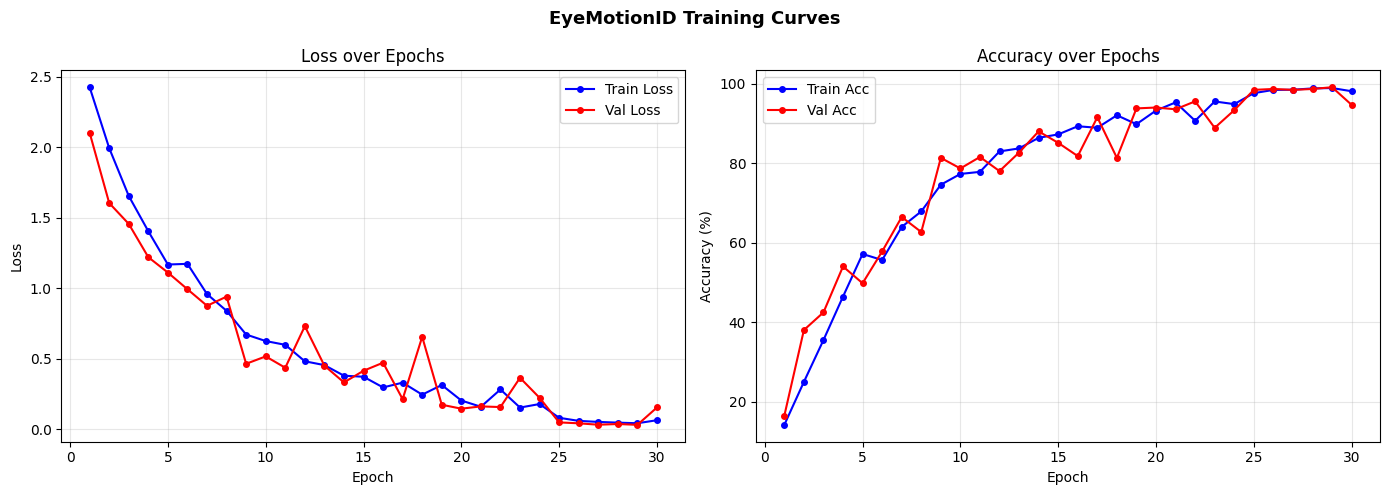

✓ Saved → /kaggle/working/training_curves.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EyeMotionID Training Curves", fontsize=13, fontweight='bold')

epochs = range(1, EPOCHS+1)

# loss curves
axes[0].plot(epochs, train_losses, 'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs, val_losses,   'r-o', markersize=4, label='Val Loss')
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# accuracy curves
axes[1].plot(epochs, [a*100 for a in train_accs], 'b-o', markersize=4, label='Train Acc')
axes[1].plot(epochs, [a*100 for a in val_accs],   'r-o', markersize=4, label='Val Acc')
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/training_curves.png", dpi=100)
plt.show()
print("✓ Saved → /kaggle/working/training_curves.png")

### Test set evaluation

In [7]:
# load best model
model.load_state_dict(torch.load(f"{OUTPUT}/best_model.pth"))
model.eval()

# evaluate on test set
test_loss, test_acc = eval_epoch(model, test_loader, criterion, device)

print("=== Test Set Results ===\n")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.2%}")
print(f"Best Val Acc  : {best_val_acc:.2%}")
print()
print(f"Users identified : {N_USERS}")
print(f"Random baseline  : {1/N_USERS:.2%} (1/{N_USERS})")
print(f"Our model        : {test_acc:.2%}")
print(f"Improvement      : {test_acc - 1/N_USERS:.2%} above random")


=== Test Set Results ===

Test Loss     : 0.0631
Test Accuracy : 98.22%
Best Val Acc  : 99.11%

Users identified : 15
Random baseline  : 6.67% (1/15)
Our model        : 98.22%
Improvement      : 91.56% above random


### Summary

In [8]:
print("=" * 50)
print("   DAY 17 — MODEL TRAINING SUMMARY")
print("=" * 50)
print()
print(f"Model     : EyeMotionID (CNN + LSTM)")
print(f"Dataset   : EyeDentify ({N_USERS} users)")
print(f"Device    : {device}")
print(f"Epochs    : {EPOCHS}")
print()
print(f"Results:")
print(f"  Best Val Accuracy  : {best_val_acc:.2%}")
print(f"  Test Accuracy      : {test_acc:.2%}")
print(f"  Random baseline    : {1/N_USERS:.2%}")
print()
print("Saved:")
print(f"  ✓ best_model.pth")
print(f"  ✓ training_curves.png")
print()
print("Next → Day 18: User Identification + Confusion Matrix")
print("=" * 50)

   DAY 17 — MODEL TRAINING SUMMARY

Model     : EyeMotionID (CNN + LSTM)
Dataset   : EyeDentify (15 users)
Device    : cuda
Epochs    : 30

Results:
  Best Val Accuracy  : 99.11%
  Test Accuracy      : 98.22%
  Random baseline    : 6.67%

Saved:
  ✓ best_model.pth
  ✓ training_curves.png

Next → Day 18: User Identification + Confusion Matrix
